In [34]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

from sklearn.preprocessing import MinMaxScaler
import joblib

In [35]:
# Load the dataset
df = pd.read_csv("irrigation_machine.csv")

In [36]:
# first 5 rows to be printed
df.head()

,Unnamed: 0,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,parcel_0,parcel_1,parcel_2
0,0,1.0,2.0,1.0,7.0,0.0,1.0,1.0,4.0,0.0,...,8.0,1.0,0.0,2.0,1.0,9.0,2.0,0,1,0
1,1,5.0,1.0,3.0,5.0,2.0,2.0,1.0,2.0,3.0,...,4.0,5.0,5.0,2.0,2.0,2.0,7.0,0,0,0
2,2,3.0,1.0,4.0,3.0,4.0,0.0,1.0,6.0,0.0,...,3.0,3.0,1.0,0.0,3.0,1.0,0.0,1,1,0
3,3,2.0,2.0,4.0,3.0,5.0,0.0,3.0,2.0,2.0,...,4.0,1.0,1.0,4.0,1.0,3.0,2.0,0,0,0
4,4,4.0,3.0,3.0,2.0,5.0,1.0,3.0,1.0,1.0,...,1.0,3.0,2.0,2.0,1.0,1.0,0.0,1,1,0


In [37]:
df.info

<bound method DataFrame.info of       Unnamed: 0  sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0              0       1.0       2.0       1.0       7.0       0.0       1.0   
1              1       5.0       1.0       3.0       5.0       2.0       2.0   
2              2       3.0       1.0       4.0       3.0       4.0       0.0   
3              3       2.0       2.0       4.0       3.0       5.0       0.0   
4              4       4.0       3.0       3.0       2.0       5.0       1.0   
...          ...       ...       ...       ...       ...       ...       ...   
1995        1995       4.0       1.0       2.0       2.0       1.0       1.0   
1996        1996       1.0       3.0       3.0       3.0       2.0       2.0   
1997        1997       1.0       3.0       3.0       1.0       1.0       4.0   
1998        1998       2.0       1.0       0.0       2.0       2.0       0.0   
1999        1999       0.0       1.0       4.0       1.0       2.0       2.0   

      s

In [38]:
df.columns #gives the column names

Index(['Unnamed: 0', 'sensor_0', 'sensor_1', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19',
       'parcel_0', 'parcel_1', 'parcel_2'],
      dtype='object')

In [39]:
df=df.drop('Unnamed: 0',axis=1) #drops the 'unnamed 0 ' column
df.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,parcel_0,parcel_1,parcel_2
0,1.0,2.0,1.0,7.0,0.0,1.0,1.0,4.0,0.0,3.0,...,8.0,1.0,0.0,2.0,1.0,9.0,2.0,0,1,0
1,5.0,1.0,3.0,5.0,2.0,2.0,1.0,2.0,3.0,1.0,...,4.0,5.0,5.0,2.0,2.0,2.0,7.0,0,0,0
2,3.0,1.0,4.0,3.0,4.0,0.0,1.0,6.0,0.0,2.0,...,3.0,3.0,1.0,0.0,3.0,1.0,0.0,1,1,0
3,2.0,2.0,4.0,3.0,5.0,0.0,3.0,2.0,2.0,5.0,...,4.0,1.0,1.0,4.0,1.0,3.0,2.0,0,0,0
4,4.0,3.0,3.0,2.0,5.0,1.0,3.0,1.0,1.0,2.0,...,1.0,3.0,2.0,2.0,1.0,1.0,0.0,1,1,0


In [40]:
df.describe #it gives the statistics of data

<bound method NDFrame.describe of       sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  \
0          1.0       2.0       1.0       7.0       0.0       1.0       1.0   
1          5.0       1.0       3.0       5.0       2.0       2.0       1.0   
2          3.0       1.0       4.0       3.0       4.0       0.0       1.0   
3          2.0       2.0       4.0       3.0       5.0       0.0       3.0   
4          4.0       3.0       3.0       2.0       5.0       1.0       3.0   
...        ...       ...       ...       ...       ...       ...       ...   
1995       4.0       1.0       2.0       2.0       1.0       1.0       1.0   
1996       1.0       3.0       3.0       3.0       2.0       2.0       3.0   
1997       1.0       3.0       3.0       1.0       1.0       4.0       8.0   
1998       2.0       1.0       0.0       2.0       2.0       0.0       1.0   
1999       0.0       1.0       4.0       1.0       2.0       2.0       6.0   

      sensor_7  sensor_8  sen

In [41]:
#X-- feature -- independent
#y -- label -- dependent
X=df.iloc[:,0:20]
y= df.iloc[:,20:]

In [42]:
X.sample(10)

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19
1275,0.0,3.0,2.0,1.0,1.0,1.0,7.0,3.0,0.0,1.0,1.0,1.0,5.0,0.0,3.0,0.0,0.0,4.0,1.0,1.0
65,1.0,1.0,1.0,3.0,5.0,1.0,2.0,7.0,0.0,0.0,5.0,4.0,3.0,4.0,4.0,0.0,4.0,0.0,2.0,2.0
1579,1.0,3.0,4.0,1.0,3.0,2.0,1.0,2.0,5.0,3.0,4.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,4.0
1478,1.0,1.0,2.0,3.0,0.0,1.0,4.0,6.0,0.0,2.0,5.0,5.0,6.0,3.0,2.0,2.0,3.0,2.0,3.0,1.0
181,2.0,4.0,5.0,3.0,6.0,1.0,5.0,8.0,0.0,1.0,4.0,5.0,6.0,10.0,0.0,0.0,2.0,2.0,4.0,2.0
1609,1.0,3.0,2.0,1.0,3.0,5.0,3.0,3.0,5.0,4.0,4.0,1.0,3.0,7.0,2.0,1.0,5.0,3.0,4.0,3.0
1187,1.0,3.0,1.0,2.0,3.0,1.0,2.0,3.0,1.0,0.0,1.0,3.0,1.0,4.0,4.0,1.0,5.0,3.0,1.0,3.0
1707,4.0,3.0,6.0,3.0,3.0,1.0,5.0,1.0,1.0,2.0,1.0,2.0,5.0,2.0,3.0,4.0,1.0,2.0,4.0,0.0
1692,1.0,3.0,3.0,1.0,5.0,0.0,10.0,6.0,1.0,0.0,5.0,1.0,5.0,1.0,3.0,0.0,4.0,6.0,0.0,0.0
213,1.0,0.0,6.0,2.0,4.0,0.0,0.0,5.0,0.0,2.0,5.0,7.0,3.0,3.0,9.0,3.0,3.0,1.0,1.0,2.0


In [43]:
y.sample(10)

,parcel_0,parcel_1,parcel_2
1475,1,1,0
1916,1,0,0
757,1,1,0
514,0,1,0
260,1,1,0
1465,1,1,0
1223,0,0,0
122,1,1,1
1942,1,1,0
741,0,1,0


In [44]:
X.info

<bound method DataFrame.info of       sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  \
0          1.0       2.0       1.0       7.0       0.0       1.0       1.0   
1          5.0       1.0       3.0       5.0       2.0       2.0       1.0   
2          3.0       1.0       4.0       3.0       4.0       0.0       1.0   
3          2.0       2.0       4.0       3.0       5.0       0.0       3.0   
4          4.0       3.0       3.0       2.0       5.0       1.0       3.0   
...        ...       ...       ...       ...       ...       ...       ...   
1995       4.0       1.0       2.0       2.0       1.0       1.0       1.0   
1996       1.0       3.0       3.0       3.0       2.0       2.0       3.0   
1997       1.0       3.0       3.0       1.0       1.0       4.0       8.0   
1998       2.0       1.0       0.0       2.0       2.0       0.0       1.0   
1999       0.0       1.0       4.0       1.0       2.0       2.0       6.0   

      sensor_7  sensor_8  senso

In [45]:
y.info

<bound method DataFrame.info of       parcel_0  parcel_1  parcel_2
0            0         1         0
1            0         0         0
2            1         1         0
3            0         0         0
4            1         1         0
...        ...       ...       ...
1995         0         0         0
1996         1         1         1
1997         1         0         0
1998         0         1         0
1999         1         1         1

[2000 rows x 3 columns]>

In [46]:
X

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19
0,1.0,2.0,1.0,7.0,0.0,1.0,1.0,4.0,0.0,3.0,1.0,3.0,6.0,8.0,1.0,0.0,2.0,1.0,9.0,2.0
1,5.0,1.0,3.0,5.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,2.0,2.0,4.0,5.0,5.0,2.0,2.0,2.0,7.0
2,3.0,1.0,4.0,3.0,4.0,0.0,1.0,6.0,0.0,2.0,3.0,2.0,4.0,3.0,3.0,1.0,0.0,3.0,1.0,0.0
3,2.0,2.0,4.0,3.0,5.0,0.0,3.0,2.0,2.0,5.0,3.0,1.0,2.0,4.0,1.0,1.0,4.0,1.0,3.0,2.0
4,4.0,3.0,3.0,2.0,5.0,1.0,3.0,1.0,1.0,2.0,4.0,5.0,3.0,1.0,3.0,2.0,2.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,4.0,3.0,3.0,1.0,2.0,3.0,2.0,1.0,1.0,0.0
1996,1.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,1.0,5.0,2.0,2.0,4.0,3.0,3.0,0.0,1.0,0.0,6.0,2.0
1997,1.0,3.0,3.0,1.0,1.0,4.0,8.0,1.0,0.0,0.0,3.0,2.0,4.0,2.0,3.0,4.0,4.0,4.0,1.0,0.0
1998,2.0,1.0,0.0,2.0,2.0,0.0,1.0,3.0,0.0,0.0,0.0,5.0,2.0,2.0,4.0,0.0,2.0,0.0,3.0,0.0


In [47]:
X.shape,y.shape # gives rows and cols

((2000, 20), (2000, 3))

In [48]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.125     , 0.22222222, 0.1       , ..., 0.09090909, 0.9       ,
        0.28571429],
       [0.625     , 0.11111111, 0.3       , ..., 0.18181818, 0.2       ,
        1.        ],
       [0.375     , 0.11111111, 0.4       , ..., 0.27272727, 0.1       ,
        0.        ],
       ...,
       [0.125     , 0.33333333, 0.3       , ..., 0.36363636, 0.1       ,
        0.        ],
       [0.25      , 0.11111111, 0.        , ..., 0.        , 0.3       ,
        0.        ],
       [0.        , 0.11111111, 0.4       , ..., 0.45454545, 0.2       ,
        0.14285714]])

In [49]:
#train-test- split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [50]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 20), (400, 20), (1600, 3), (400, 3))

In [51]:
# train classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
rf = RandomForestClassifier(
    n_estimators=200, # Number of trees
    max_depth=10,  # Maximum depth of each tree
    min_samples_split=4,  # Minimum samples to split a node
    min_samples_leaf=2, # Minimum samples per leaf
    max_features='sqrt', # Number of features to consider at each split ('auto', 'sqrt', 'log2', or int)
    random_state=42
)
# Wrap it with MultiOutputClassifier
model = MultiOutputClassifier(rf)

# Train the model
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       max_features='sqrt',
                                                       min_samples_leaf=2,
                                                       min_samples_split=4,
                                                       n_estimators=200,
                                                       random_state=42))

In [52]:
# model evaluate
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=y.columns))

Classification Report:
              precision    recall  f1-score   support

    parcel_0       0.87      0.93      0.90       256
    parcel_1       0.91      0.97      0.94       304
    parcel_2       0.93      0.48      0.64        87

   micro avg       0.89      0.89      0.89       647
   macro avg       0.90      0.80      0.83       647
weighted avg       0.90      0.89      0.88       647
 samples avg       0.82      0.79      0.79       647



c:\Users\swath\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\swath\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [53]:
print(df[['parcel_0', 'parcel_1', 'parcel_2']].sum())

parcel_0    1271
parcel_1    1461
parcel_2     424
dtype: int64


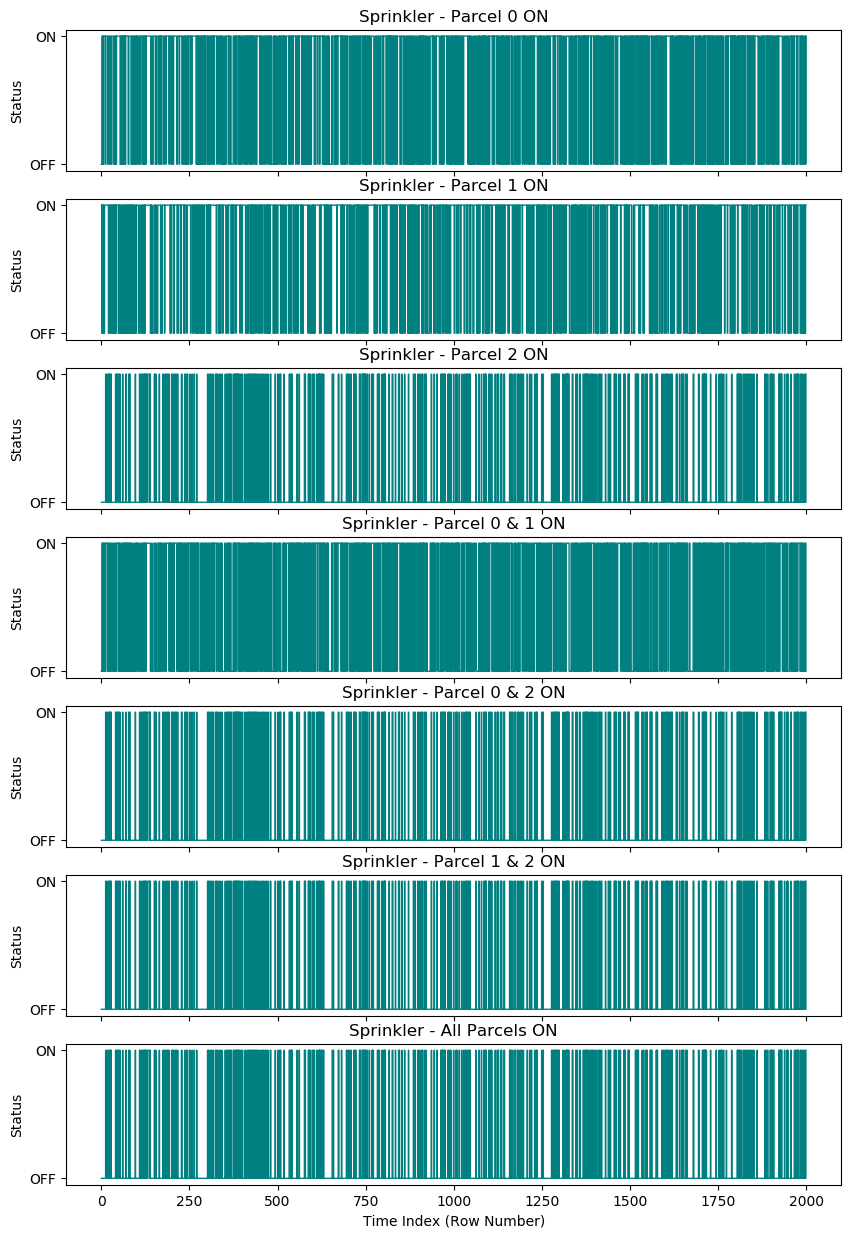

In [54]:
import matplotlib.pyplot as plt
#define parcel activation conditions with descriptive labels
conditions = {
    "Parcel 0 ON": df['parcel_0'],
    "Parcel 1 ON": df['parcel_1'],
    "Parcel 2 ON": df['parcel_2'],
    "Parcel 0 & 1 ON": df['parcel_0'] & df['parcel_1'],
    "Parcel 0 & 2 ON": df['parcel_0'] & df['parcel_2'],
    "Parcel 1 & 2 ON": df['parcel_1'] & df['parcel_2'],
    "All Parcels ON": df['parcel_0'] & df['parcel_1'] & df['parcel_2'],
}
#create vertically stacked subplots (one for each condition)
fig, axs = plt.subplots(nrows=len(conditions), figsize=(10,15), sharex=True)
#loop through each condition to plot corresponding square wave
for ax, (title, condition) in zip(axs, conditions.items()):
    ax.step(df.index, condition.astype(int), where='post', linewidth=1, color='teal')
    ax.set_title(f"Sprinkler - {title}")
    ax.set_ylabel("Status")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['OFF', 'ON'])
# label x-axis on the last subplot
axs[-1].set_xlabel("Time Index (Row Number)")
plt.show()

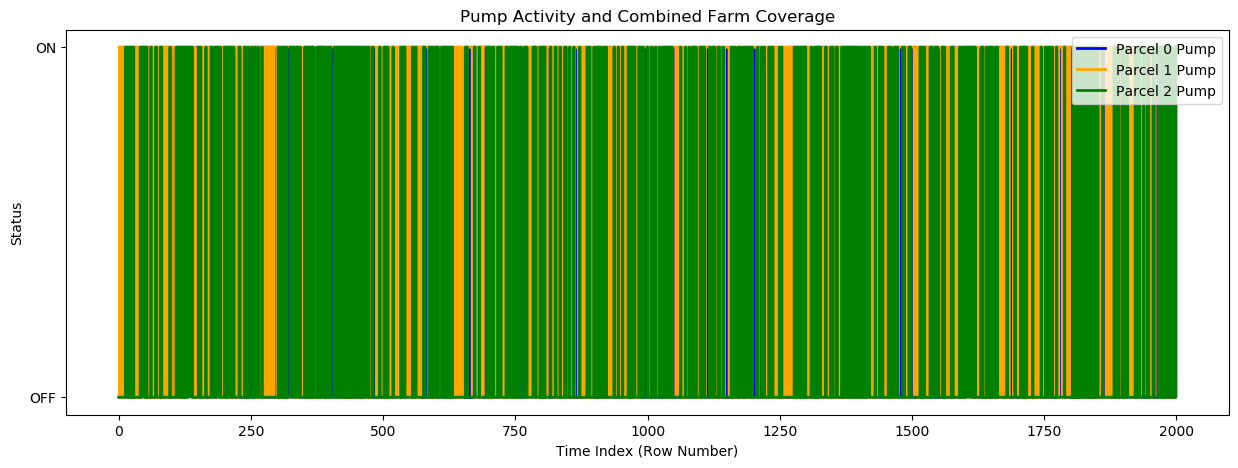

In [55]:
# calculate combined activity of all pumps (overlap)
any_pump_on = (df['parcel_0'] == 1) | (df['parcel_1'] == 1) | (df['parcel_2'] == 1)
plt.figure(figsize=(15, 5))
# plot individual pump statuses
plt.step(df.index, df['parcel_0'], where='post', linewidth=2, label='Parcel 0 Pump', color='blue')
plt.step(df.index, df['parcel_1'], where='post', linewidth=2, label='Parcel 1 Pump', color='orange')
plt.step(df.index, df['parcel_2'], where='post', linewidth=2, label='Parcel 2 Pump', color='green')
plt.title("Pump Activity and Combined Farm Coverage")
plt.xlabel("Time Index (Row Number)")
plt.ylabel("Status")
plt.yticks([0, 1], ['OFF', 'ON'])
plt.legend(loc='upper right')
plt.show()

In [56]:
import joblib
from sklearn.pipeline import Pipeline
joblib.dump(model, "Farm_Irrigation_System.pkl")

['Farm_Irrigation_System.pkl']